<a href="https://colab.research.google.com/github/Jungwon06/opensource-project/blob/model/pill_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 드라이브 마운트 및 라이브러리 로드

In [7]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. 하이퍼파라미터 및 데이터 전처리 설정

In [8]:
# 경로 및 기본 하이퍼파라미터 설정
DATA_DIR = '/content/drive/MyDrive/processed_dataset'
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.0001

# 이미지 변형 및 정규화 설정
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 데이터로더 구축
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), data_transforms['val'])
}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Dataset Summary: {num_classes} classes found.")
print(f"Classes: {class_names}")
print(f"Train size: {dataset_sizes['train']} | Val size: {dataset_sizes['val']}")

Dataset Summary: 13 classes found.
Classes: ['Acetaminophen', 'Aspirin', 'Ciprofloxacin', 'Dexibuprofen', 'Famotidine', 'Ibuprofen', 'Itraconazole', 'Lamotrigine', 'Loperamide', 'MagnesiumHydroxide', 'Naproxen', 'Nizatidine', 'Warfarin']
Train size: 648 | Val size: 29


# 3. 전이학습 모델 정의 (ResNet50)

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Pre-trained ResNet50 로드 및 가중치 설정
model_ft = models.resnet50(pretrained=True)

# 최종 분류 레이어를 클래스 수에 맞게 수정
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=LEARNING_RATE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


# 4. 모델 학습 및 검증 루프 함수

In [10]:
def train_model(model, criterion, optimizer, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    print(f'Training complete. Best Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

# 5. 학습 실행 및 가중치 저장

In [11]:
# 학습 진행
best_model, history = train_model(model_ft, criterion, optimizer_ft, num_epochs=NUM_EPOCHS)

# 최종 모델 가중치 저장
torch.save(best_model.state_dict(), os.path.join(DATA_DIR, 'best_pill_model.pth'))

Epoch 1/10
--------------------
Train Loss: 1.1439 Acc: 0.7423
Val Loss: 0.1828 Acc: 0.9310

Epoch 2/10
--------------------
Train Loss: 0.1183 Acc: 0.9753
Val Loss: 0.1210 Acc: 0.9655

Epoch 3/10
--------------------
Train Loss: 0.0497 Acc: 0.9969
Val Loss: 0.1358 Acc: 0.9655

Epoch 4/10
--------------------
Train Loss: 0.0216 Acc: 0.9969
Val Loss: 0.0981 Acc: 0.9655

Epoch 5/10
--------------------
Train Loss: 0.0262 Acc: 1.0000
Val Loss: 0.0956 Acc: 0.9655

Epoch 6/10
--------------------
Train Loss: 0.0177 Acc: 0.9969
Val Loss: 0.0794 Acc: 0.9655

Epoch 7/10
--------------------
Train Loss: 0.0251 Acc: 0.9923
Val Loss: 0.0588 Acc: 0.9655

Epoch 8/10
--------------------
Train Loss: 0.0308 Acc: 0.9938
Val Loss: 0.0853 Acc: 0.9655

Epoch 9/10
--------------------
Train Loss: 0.0155 Acc: 0.9969
Val Loss: 0.0478 Acc: 1.0000

Epoch 10/10
--------------------
Train Loss: 0.0094 Acc: 1.0000
Val Loss: 0.0318 Acc: 1.0000

Training complete. Best Val Acc: 1.0000


# 6. 학습 곡선 시각화

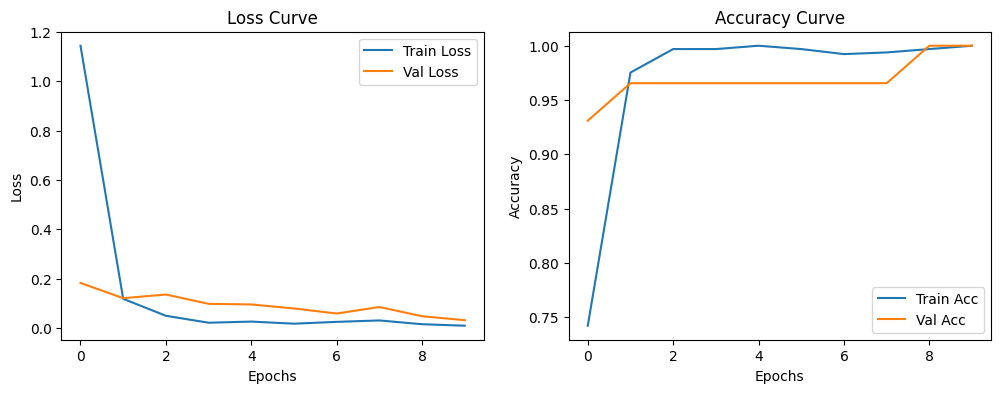

In [12]:
import matplotlib.pyplot as plt

# 학습 곡선(Loss & Accuracy) 시각화
plt.figure(figsize=(12, 4))

# 1. Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# 2. Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

# 7. Test 데이터 기반 Confusion matrix 도출

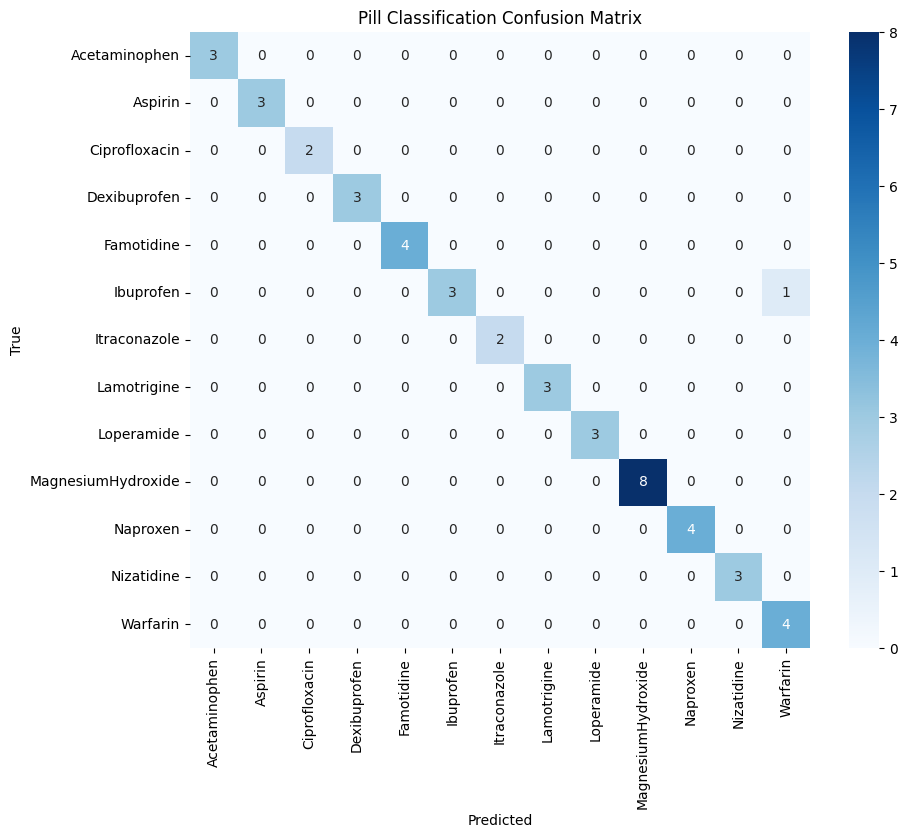

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 혼동 행렬 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Pill Classification Confusion Matrix')
plt.show()